<a href="https://colab.research.google.com/github/ndanilova/Data_Analysis/blob/main/module_4/lab1/lab_1_AutoML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Быстрый старт с AutoML

Если нет опыта в разработке моделей машинного обучения или не очень ясно, с чего начать анализ и какой алгоритм выбрать, удобно начать с автоматического машинного обучения или AutoML. Его принцип в том, что некий фреймворк за вас подготавливает данные, выбирает алгоритм и проводит тестирование либо по данным вами критетериям, либо по тем, которые больше всего подходят под данные.

Существуют как фреймворки для AutoML, которые буквально в пару строчек кода создадут модель машинного обучения, не требуя от пользователя погружения в детали реализации, так и полноценное ПО, которое может работать по принципу drag-and-drop. Во втором случае даже код писать не нужно, только понимать, что к чему и чего хочется.

В этом практикуме рассмотрим 3 простых фреймворка: AutoGluon, h2o.ai, FLAML.

## Примеры

Для начала загрузим данные для первых двух примеров. Это будут объемные, но уже достаточно старые (2017 год) табличные данные о продаже недвижимости от Сбера. Будем работать с немножко предобработанной версией датасета с kaggle: https://www.kaggle.com/datasets/matthewa313/sberbankdatafix/data

Также в разделе Competitions там же можно найти исходные данные.

Если у вас нет аккаунта на kaggle, то вы можете создать его через google-почту, акканут вам понадобится для загрузки данных.

Создав аккаунт, перейдите в профиль пользователя (кликнув на иконку в правом верхнем углу и выбрав пункт Settings) и выполните следующие шаги для того, чтобы узнать (или создать) свой юзернейм и токен:
1. Долистайте до раздела API.
2. Нажмите Create New Token и сохраните сформировавшийся json.
3. Далее можете подгрузить файл в сессию колаба или просто скопировать из него данные, когда у вас их запросят парой ячеек ниже.

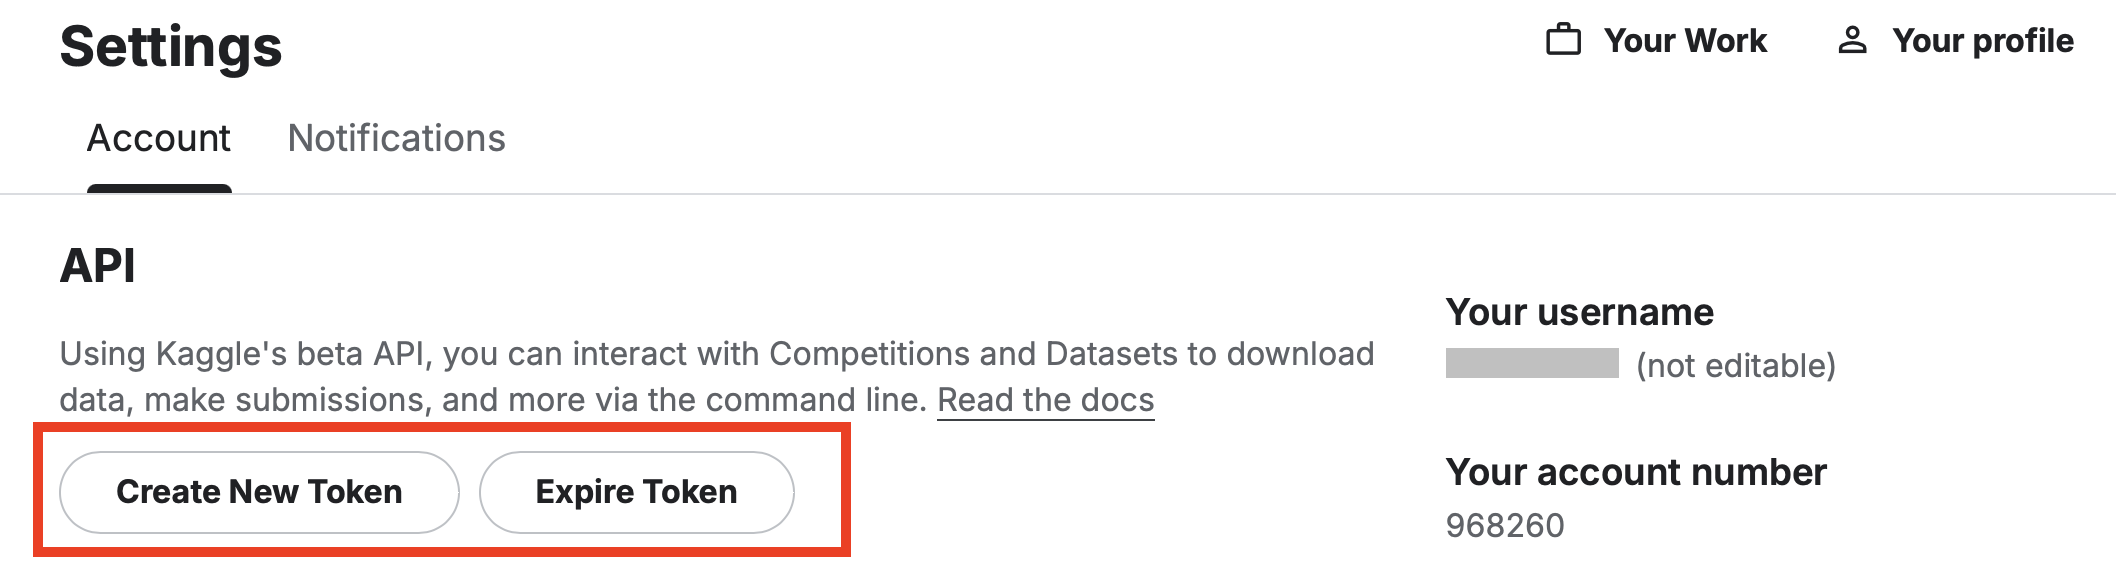

Скачать данные из некоторых открытых источников, включая kaggle, можно с помощью библиотеки `opendatasets`. Ею и воспользучемся, чтобы не скачивать файлы вручную и не тратить время на соединение колаба с kaggle.

Для установки и импорта библиотеки запустите следующие три ячейки.

In [ ]:
%%capture
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd  # понадобится для печати и обработки таблиц

In [ ]:
dataset_url = 'https://www.kaggle.com/datasets/matthewa313/sberbankdatafix/data'
od.download(dataset_url)

Выведем первые несколько строк таблицы с данными и размер.

In [ ]:
df = pd.read_csv("/content/sberbankdatafix/train_without_noise.csv")
display(df.head())
print(df.shape)

Видим, что здесь около 300 столбцов (признаков). В этом практикуме не будем подробно погружаться в их суть, но по-хорошему это нужно делать, и этот процесс называется исследовательский анализ данных или EDA.

Кратко: данные представляют собой описание характеристик проданной недвижимости в Москве и цену каждого объекта, которая хранится в столбце `price_doc`. Сложно придумать более классическую задачу машинного обучения, чем предсказание цены на жилье, но в этих данных ситуация осложняется множеством полупустых столбцов и достаточно большим объемом данных.

### AutoGluon

Теперь попробуем обучить модель регрессионную модель с помощью библиотеки AutoGluon: https://auto.gluon.ai/stable/index.html

Помимо построения моделей для табличных данных, библиотека также умеет решать задачи обработки текста (NLP) и распознавания образов.

Установка занимает около 2 минут.

In [ ]:
%%capture
!pip install autogluon

Загрузим данные и разделим их обучающую и тестовую выборки. Суть в том, что при обучении модели мы будем показывать ей набор характеристик объекта и правильный ответ в надежде, что на достаточно большом объеме данных, она запомнит принцип, по которому надо давать правильный ответ. При этом модель может запомнить не принцип (паттерн), а сами данные. Чтобы проверить, что такого не произошло, нам необходима тестовая выборка, которую в процессе обучения модель не видит. Чем выше и сбалансированнее будут метрики качества на обеих выборках, тем выше вероятность, что построенная модель обладает хорошей обобщающей способностью, то есть она способна делать предсказания на данных, которые ранее не видела.

Разбивать данные на подвыборки будем случайным образом в соотношении 80/20: 80% для обучения, 20% - для тестирования.

In [ ]:
from autogluon.tabular import TabularPredictor, TabularDataset
from sklearn.model_selection import train_test_split

data = TabularDataset("/content/sberbankdatafix/train_without_noise.csv")  # загрузка данных
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)  # разделение на подвыборки

Loaded data from: /content/sberbankdatafix/train_without_noise.csv | Columns = 292 / 292 | Rows = 28895 -> 28895


Это все. Теперь можно переходить к обучению. Для этого создадим предиктор, которому передадим целевую переменную - в нашем случае `price_doc`.

Почитайте лог при запуске ячейки. В нем вы увидите, как фреймворк сам определил, какую задачу машинного обучения ему нужно решить на основе распределения значений целевой переменной, а также какую метрику он выбрал и как проходит процесс обучения каждой из рассматриваемых моделей.

По умолчанию сейчас все настройки ппроисходят автоматически, но в документации можно подробно ознакомиться с тонкими настройками процесса. Например, можно выбрать, какие именно алгоритмы и с каким набором гиперпараметров нужно протестировать.

Довольно часто случается, что AutoGluon неверно угадывает задачу машинного обучения на основе данных в столбце с целевой переменной. В этом случае можно явно ее прописать, выглядеть это будет так:
```
predictor = TabularPredictor(label="col_name", problem_type="ml_task_type").fit(...)
```

Но для начала посмотрим, успешно ли пройдет автоматическое обучение без подсказок.

In [ ]:
predictor = TabularPredictor(label="price_doc").fit(
    train_data,  # тренировочная выборка
    presets="best_quality",  # ориентируемся на лучшее качество
    time_limit=300  # 5 минут на обучение, можно сократить до 3 минут
)

Теперь посмотрим на таблицу лидеров среди рассмотренных фреймворком алгоритмов. Видим, что побеждают явно ансамблевые методы, а первые 3 еще и работают с примерно одинаковой ошибкой за примерно одинаковое время.

In [ ]:
leaderboard = predictor.leaderboard()
leaderboard

Проверим обобщающую способность модели. Для этого оценим ее на обучающей (тренировочной) выборке и тестовой. В выводах ниже у некоторых метрик может стоять знак минус, хотя по логике такого не может быть, скажем, отрицательного корня в RMSE. Это особенность автоматической настройки AutoGluon для удобства сортировки результатов. Можно ориентироваться на абсолютное значение.

In [ ]:
predictor.evaluate(train_data)

In [ ]:
predictor.evaluate(test_data)

По результатам видим, что достаточно неплохой коэффициент детерминации $R^2$. Выше 0.5 - уже хорошо. RMSE и MAE достаточно высокие, модели ошибается в цене примерно на 1.5 млн. Это, конечно же, много для цены на недвижимость. Но! Мы не занимались никакой инженерией признаков, даже автоматической. Проведя ее, на этих данных можно снизить ошибку примерно до 500 тысяч.

Кроме того, AutoGluon позволяет оценивать значимость признаков. То есть какие характеристики жилья вносят наибольший вклад в предсказание. Если рассмотреть табличку ниже, то можно увидеть, что наибольший вклад в цену жилья вносят различные характеристики площади: жилой/нежилой/общей, число комнат и развитость инфраструктуры. Что логично.

In [ ]:
predictor.feature_importance(data=train_data, time_limit=180)

Теперь посмотрим, как сделать предсказание, а не просто посчитать метрики. Для этого потребуется метод `predict`. Предварительно удалим из тестовых данных целевую переменную.

In [ ]:
y_true = test_data[["price_doc"]]
y_true.columns = ["true_price"]
test_data = test_data.drop(columns=["price_doc"])

А сейчас можно сделать предсказание. Заодно построим сравнительную таблицу, чтобы посмотреть, для каких объектов предсказание получилось наименее точным.

In [ ]:
y_pred = predictor.predict(test_data)

In [ ]:
result = pd.concat([y_true, y_pred], axis=1)
result["diff"] = (result["true_price"]-result["price_doc"]).abs()
result.sort_values(by=["diff"], ascending=False)

Видим, что в топе объекты с разнице аж в 60 млн, а самые успешные предсказания угадывают цену с точностью до 100 рублей. В среднем же ошибка – 1.5 млн, как мы уже выяснили выше. Разбираться, а почему такие большие разницы и почему так вышло, - это уже задача номер 2. AutoML свою выполнил - сделал первое приближение.

### h2o.ai

Второй очень популярный фреймворк, который также существует в качестве дектопного ПО и веб-приложения, – это h2o (https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html). Достаточно часто именно его считают SOTA-решением в области AutoML. Принцип работы в целом такой же, как в AutoGluon. Подаем на вход данные, описываем свои возможности по времени и ждем результат.

У h2o, кстати, удобная веб-версия, можно поэкспериментировать на досуге.

Следующие две ячейки устанавливают и инициализируют фреймворк в колабе.

In [ ]:
%%capture
!pip install h2o

In [ ]:
import h2o
h2o.init()

Снова загрузим данные. Оставим те же, что в первом примере, чтобы сравнить, как другой фреймворк справится с той же задачей на автоматических настройках. Разбивать на обучающую и тестовую выборки будем в том же соотношении, что и раньше, – создаем одинаковые условия для эксперимента.

In [ ]:
data = h2o.import_file("/content/sberbankdatafix/train_without_noise.csv")
train_data, test_data = data.split_frame(ratios=[0.8])

Запустим модель. Здесь это делается с помощью метода `train`. Переберем не более 10 моделей за 5 минут, как было в примере с AutoGluon.

In [ ]:
from h2o.automl import H2OAutoML
model = H2OAutoML(max_models=10, max_runtime_secs=300, seed=42)
model.train(y="price_doc", training_frame=train_data)

В логе можем прочитать, что лучшей снова оказалась вариация градиентного бустинга, но уже другая. Эта модель примерно на 200 тысяч меньше ошибается в предсказании цены, а наиболее значимыми считает те же самые характеристики.

Тоже посмотрим на предсказания и наиболее сильные различия.

In [ ]:
y_true = test_data[["price_doc"]]
test_data = test_data.drop("price_doc")

In [ ]:
y_pred = model.leader.predict(test_data)

In [ ]:
result = pd.concat([y_true.as_data_frame(), y_pred.as_data_frame()], axis=1)
result["diff"] = (result["price_doc"]-result["predict"].round()).abs().round()
result.sort_values(by=["diff"], ascending=False)

Как видим, результат оказывается получше, но очень схожим с тем, который был получен с помощью AutoGluon. При большем временном ресурсе, более тонкой настройке параметров и инженерии признаков можно добиться еще более удачных предсказаний.

### FLAML

Еще один AutoML-инструмент на этот раз – от Microsoft: https://microsoft.github.io/FLAML/docs/getting-started

В целом концепция работы та же самая: передаем модели данные, указываем имеющиеся ресурсы, но теперь нужно еще прописать, какую задачу нужно решить. Помимо классических ML-задач, фреймворк также предоставляет возможность автоматической работы с генеративными моделями. Советую посмотреть эту фичу отдельно.

Установка в текущей версии колаба немного сложнее предыдущих. После запуска следующей ячейки и установки библиотек колаб предложит вам обновить сеанс - соглашайтесь, это обновит версии и зависимости, что необходимо для корректной работы последующих ячеек.

Перезапустив сеанс, можно дальше переходить к ячейке с импортами.

In [ ]:
!pip install -U pip setuptools wheel
!pip install numpy==1.24.4
!pip install flaml

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from flaml import AutoML
from sklearn.metrics import classification_report

Для примера используем другие данные – датасет, содержащий 150к комментариев к товарам на Wildberries. Снова возьмем предобработанную версию с kaggle. Здесь рассмотрим задачу многоклассовой классификации – рейтинг, который поставил пользователь (поле `mark`).

Особенность задачи в том, что предсказание будем делать только по тексту отзыва.

In [ ]:
dataset_url = 'https://www.kaggle.com/datasets/andreykamenskiy/wildberries-comments'
od.download(dataset_url)

In [ ]:
df = pd.read_csv("/content/wildberries-comments/prepared_data.csv")
display(df.head())
print(df.shape)

Оценим сбалансированность классов.

In [ ]:
df.mark.value_counts()

Видим, что данные не сбалансированы: 120к оценок из 150к – 5 звезд. Задача не из простых. Посмотрим, как с ней справится AutoML.

Преобразуем целевую переменную в следующий формат: каждая категория является целым числом, минимальное значение, которого 0. Попробуйте сначала без этой строки и посмотрите, что скажет FLAML.

In [ ]:
df["mark"] = df["mark"].apply(int)-1

Альтернативно можно сделать то же самое с помощью LabelEncoder вот так:
```
from sklearn.preprocessing import LabelEncoder
y = df["mark"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
```

Разделим данные на обучающую и тестовую выборки.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["mark"], test_size=0.2, random_state=42)

Сделаем минимальную подготовку текста – векторизацию. Обычно требуется больше шагов предобработки для достижения более высокого качества модели, но в этом практикуме мы тестируем возможности AutoML с минимальными вводными, поэтому предобработку тоже сделаем минимальную.

In [ ]:
# 1000 - это максимальное число наиболее часто встречающихся в датасете слов
vectorizer = TfidfVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
automl = AutoML()
automl_settings = {
    "time_budget": 300,  # 5 минут на подбор модели
    "task": 'classification',  # решаем задачу классификации
    "metric": 'accuracy',  # ориентируемся на долю правильных ответов
}

In [ ]:
automl.fit(X_train_vec, y_train, **automl_settings)
y_pred = automl.predict(X_test_vec)

Если применяли LabelEncoder, то сейчас надо раскодировать значения:
```
y_pred_flaml = le.inverse_transform(y_pred)
```

In [ ]:
print(classification_report(y_test, y_pred))

Как видим, результат получился довольно успешный при минимальных вводных. Лучше всего распознается рейтинг 5, но там и примеров больше всего. При этом остальные классы тоже предсказываются с точностью от 70%.

>Получились ли при ваших запусках такие же результаты, как в комментариях к колабу?

## Задание

Вы запустили и рассмотрели 3 примера решения задач с помощью AutoML. Теперь вам предстоит самостоятельно решить несколько новых задач:
1. [FIFA 22 complete player dataset](https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset): несколько Мб данных за несколько версий FIFA для предсказания зарплаты игроков. Понадобится файл Career Mode player datasets - FIFA 15-22.xlsx. Поле с зарплатой игрока – это `wage_eur`.
2. [RIA News](https://www.kaggle.com/datasets/intdivrot/ria-news): 45к новостных статей с РИА Новости за 2024 год для предсказания категории новости. Решим задачу двумя способами:
 - Будем использовать только текст заголовка для предсказания.
 - Будем использовать полный текст статьи, объединив его с заголовком.

 В конце сравните результаты.

Для каждого датасета выберите один из рассмотренных фреймворков и решите с его помощью задачу предсказания. AutoGluon и h2o тоже умеют решать задачи классификации (вспомните, мы там вообще не указывали тип задачи, определить его - задача фреймфорка), а FLAML умеет решать регрессию, ему об этом надо просто сообщить в момент конфигурации. Поэтому необязательно для текстов ориентироваться на последний пример, а для предсказания стоимости на первые два. Можно выбрать любую комбинацию.

В AutoGluon есть модуль для обработки текста, можно воспользоваться им из документации или способом с векторизацией, аналогичным тому, что был в примере для FLAML, чтобы не менять контекст.


>Если результаты получаются не слишком оптимистичными, попробуйте увеличить время и дать фреймворкам возможность перебрать больше моделей и их параметров. Обычно на хороший AutoML тратится не 5 минут, как в примерах, а как минимум около часа.

Так как данные в датасете про футбол не подготовлены, выполним для начала небольшую подготовку: удалим отсутствующие значения в столбцах `value_eur` и `wage_eur`, а также пересохраним файл из `xslx` в `csv` для удобства считывания фреймворками.

In [ ]:
%%capture
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd  # понадобится для печати и обработки таблиц

In [ ]:
dataset_url = 'https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset'
od.download(dataset_url)

In [ ]:
df = pd.read_excel("/content/fifa-22-complete-player-dataset/Career Mode player datasets - FIFA 15-22.xlsx")
df = df.dropna(subset=["value_eur", "wage_eur"])
print(df.shape)
df.to_csv(df.to_csv("/content/fifa-22-complete-player-dataset/Career Mode player datasets - FIFA 15-22.csv"))

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,...,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/105035/60.png,https://cdn.sofifa.net/flags/nl.png
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,52500000.0,275000.0,32,...,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1363/60.png,https://cdn.sofifa.net/flags/se.png
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,63500000.0,300000.0,28,...,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png


(16155, 110)


Теперь для загрузки данных в модели используйте файл `df.to_csv("/content/fifa-22-complete-player-dataset/Career Mode player datasets - FIFA 15-22.csv"`.

Файлу с текстовыми данными дополнительные манипуляции такого плана понадобиться не должны.

In [ ]:
# место для вашего решения